# Network Intrusion Detection System (NIDS)
### NSL-KDD | XGBoost vs MLP PyTorch | Multi-class Classification

**Obiectiv:** Antreneaza si compara doua modele ML pentru detectarea atacurilor de retea din fluxuri de trafic.

| | Detaliu |
|---|---|
| **Dataset** | NSL-KDD Dataset |
| **Task** | Clasificare multi-clasa (Normal + tipuri de atac) |
| **Modele** | XGBoost + MLP PyTorch |
| **Metrici** | Accuracy, Precision, Recall, F1-score per clasa |

## 1. Setup & Imports

In [62]:
# Instalare pachete lipsa pe Kaggle
# !pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML clasic
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb

# Imbalance
from imblearn.under_sampling import RandomUnderSampler

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Timing
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'XGBoost: {xgb.__version__}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
XGBoost: 3.2.0
PyTorch: 2.10.0+cpu


## 2. Incarcare Date

In [63]:
import os

# Pe Kaggle - calea catre NSL-KDD
DATA_PATH = '/kaggle/input/nslkdd'

# Listeaza fisierele disponibile
for root, dirs, files in os.walk(DATA_PATH):
    for f in files:
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'{fpath}  ({size_mb:.1f} MB)')

In [64]:
# Definim manual coloanele deoarece fisierul NSL-KDD nu are header
kdd_cols = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
            'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 
            'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 
            'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 
            'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 
            'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']

# 2. Cautam automat fisierul de train ignorand numele folderelor
train_file = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'kddtrain' in f.lower() and f.endswith('.txt'):
            train_file = os.path.join(root, f)
            break
    if train_file:
        break
# 3. Citim datele
if train_file is not None:
    print(f"SUCCES: Am gasit datele la calea -> {train_file}")
    df = pd.read_csv(train_file, names=kdd_cols)
    
    # Eliminam coloana 'difficulty' (nu ne ajuta la predictii)
    if 'difficulty' in df.columns:
        df.drop('difficulty', axis=1, inplace=True)
        
    print(f"Datele au fost incarcate cu succes! Linii: {df.shape[0]} | Coloane: {df.shape[1]}")
    display(df.head())
else:
    print("EROARE CRITICA: Kaggle inca proceseaza fisierele sau dataset-ul este gol.")

SUCCES: Am gasit datele la calea -> /kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
Datele au fost incarcate cu succes! Linii: 125973 | Coloane: 42


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. EDA - Exploratory Data Analysis

In [65]:
# Identifica coloana label
label_col = 'label'
print(f'Coloana label: "{label_col}"')

# Distributia claselor
class_counts = df[label_col].value_counts()
print(f'\nClase gasite ({len(class_counts)}):')
print(class_counts)

Coloana label: "label"

Clase gasite (23):
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


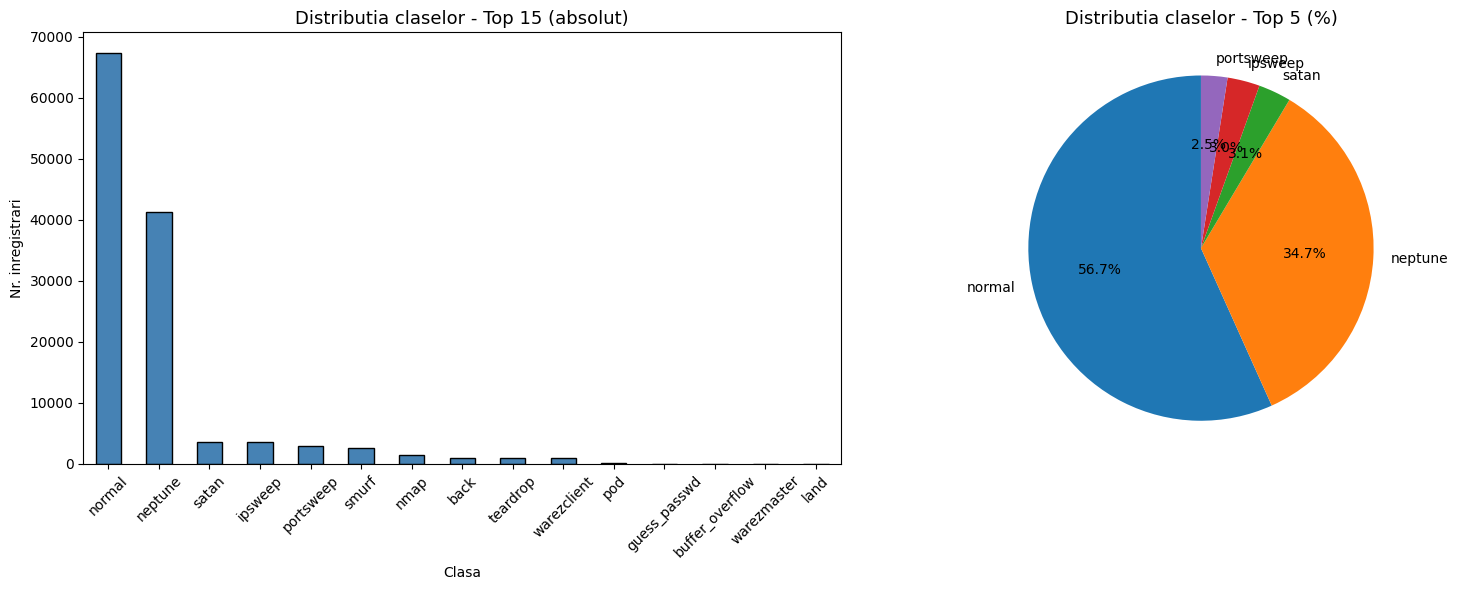


Imbalance ratio (Top vs Bottom): 33671.5x


In [66]:
# Vizualizare distributie clase
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolut - doar top 15 atacuri pentru ca NSL-KDD are multe clase mici
class_counts.head(15).plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Distributia claselor - Top 15 (absolut)', fontsize=13)
ax1.set_xlabel('Clasa')
ax1.set_ylabel('Nr. inregistrari')
ax1.tick_params(axis='x', rotation=45)

# Procentual - doar top 5 pentru claritate
top_5 = class_counts.head(5)
top_5.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Distributia claselor - Top 5 (%)', fontsize=13)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print(f'\nImbalance ratio (Top vs Bottom): {class_counts.max() / class_counts.min():.1f}x')

In [67]:
# Info general
print('=== Statistici generale ===')
print(f'Randuri: {df.shape[0]:,}')
print(f'Coloane: {df.shape[1]}')
print(f'Valori lipsa: {df.isnull().sum().sum():,}')
print(f'Valori infinite: {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}')
print(f'Duplicate: {df.duplicated().sum():,}')
print()
df.describe()

=== Statistici generale ===
Randuri: 125,973
Coloane: 42
Valori lipsa: 0
Valori infinite: 0
Duplicate: 0



,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Features cu varianta 0 (inutile): 1


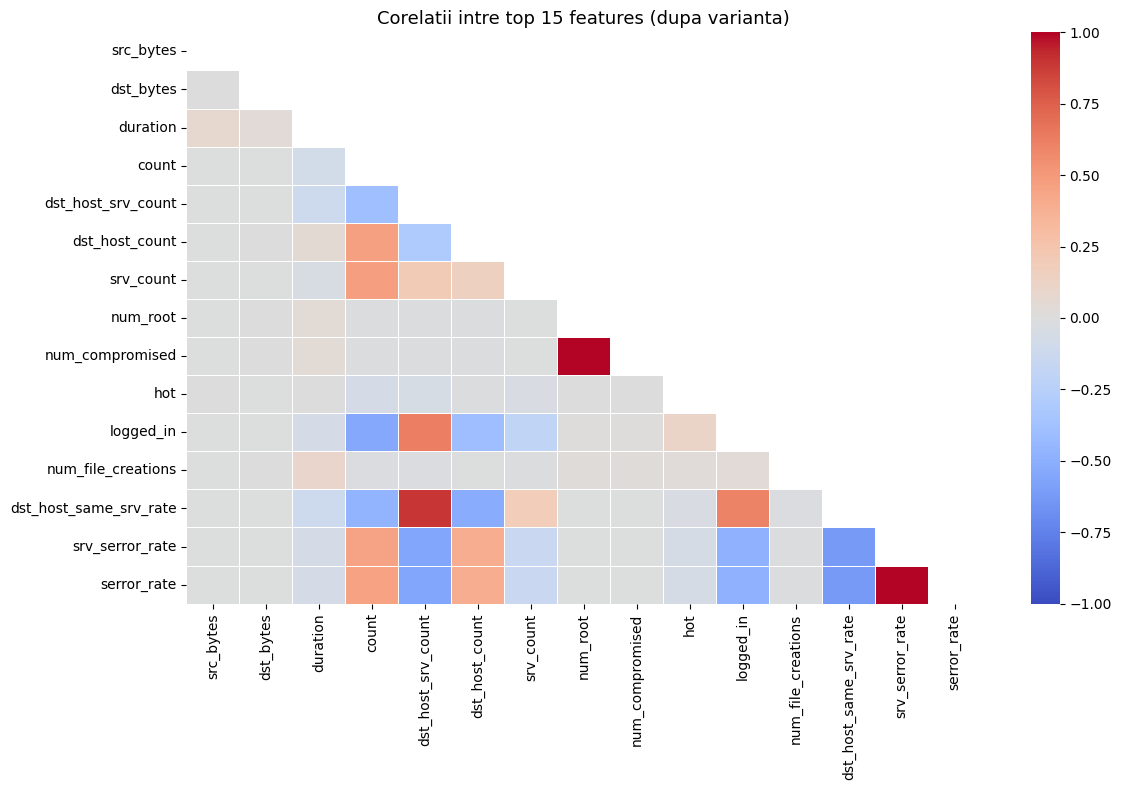

In [68]:
# Top 20 features dupa varianta - features cu varianta 0 sunt inutile
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if label_col in numeric_cols:
    numeric_cols.remove(label_col)

variances = df[numeric_cols].var().sort_values(ascending=False)
zero_var = (variances == 0).sum()
print(f'Features cu varianta 0 (inutile): {zero_var}')

# Correlation heatmap - top 15 features
top_features = variances.head(15).index.tolist()
plt.figure(figsize=(12, 8))
corr = df[top_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Corelatii intre top 15 features (dupa varianta)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [69]:
df_clean = df.copy()

# 1. Inlocuieste inf cu NaN, apoi elimina
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df_clean)
df_clean.dropna(inplace=True)
print(f'Randuri eliminate (NaN/inf): {before - len(df_clean):,}')

# 2. Elimina duplicate
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Randuri eliminate (duplicate): {before - len(df_clean):,}')

# 3. Elimina features cu varianta 0 (doar pentru numerice)
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
zero_var_cols = [c for c in numeric_cols if df_clean[c].var() == 0]
df_clean.drop(columns=zero_var_cols, inplace=True)
print(f'Coloane eliminate (var=0): {len(zero_var_cols)} -> {zero_var_cols[:5]}...')

# 4. Encoding pentru categorice (Protocol, Service, Flag)
cat_cols = ['protocol_type', 'service', 'flag']
for c in cat_cols:
    if c in df_clean.columns:
        le_cat = LabelEncoder()
        df_clean[c] = le_cat.fit_transform(df_clean[c].astype(str))
print('Coloane categorice encodate cu succes.')

# 5. Eliminam clase rare (<10 samples) ca sa nu dea eroare train_test_split (stratify)
counts = df_clean[label_col].value_counts()
rare_classes = counts[counts < 10].index
if len(rare_classes) > 0:
    df_clean = df_clean[~df_clean[label_col].isin(rare_classes)]
    print(f'Eliminate {len(rare_classes)} clase rare (<10 exemple)')

# 6. Encoding label
le = LabelEncoder()
df_clean['label_enc'] = le.fit_transform(df_clean[label_col])
class_names = list(le.classes_)
num_classes = len(class_names)
print(f'\nClase finale ({num_classes}): {class_names}')
print(f'\nDataset curat: {df_clean.shape}')

Randuri eliminate (NaN/inf): 0
Randuri eliminate (duplicate): 0
Coloane eliminate (var=0): 1 -> ['num_outbound_cmds']...
Coloane categorice encodate cu succes.
Eliminate 6 clase rare (<10 exemple)

Clase finale (17): ['back', 'buffer_overflow', 'guess_passwd', 'imap', 'ipsweep', 'land', 'neptune', 'nmap', 'normal', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'teardrop', 'warezclient', 'warezmaster']

Dataset curat: (125940, 42)


In [70]:
# Features finale
feature_cols = [c for c in df_clean.select_dtypes(include=np.number).columns
                if c not in [label_col, 'label_enc']]

X = df_clean[feature_cols].values
y = df_clean['label_enc'].values

print(f'Features: {len(feature_cols)}')
print(f'Samples: {X.shape[0]:,}')

# Handling class imbalance cu RandomUnderSampler
# Pastram max 50.000 per clasa pentru eficienta
max_per_class = 50_000
sampling_strategy = {}
for cls_idx, cls_name in enumerate(class_names):
    count = np.sum(y == cls_idx)
    sampling_strategy[cls_idx] = min(count, max_per_class)

rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_res, y_res = rus.fit_resample(X, y)
print(f'\nDupa undersampling: {X_res.shape[0]:,} samples')

# Distributie dupa sampling
unique, counts = np.unique(y_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {class_names[u]}: {c:,}')

Features: 40
Samples: 125,940

Dupa undersampling: 108,597 samples
  back: 956
  buffer_overflow: 30
  guess_passwd: 53
  imap: 11
  ipsweep: 3,599
  land: 18
  neptune: 41,214
  nmap: 1,493
  normal: 50,000
  pod: 201
  portsweep: 2,931
  rootkit: 10
  satan: 3,633
  smurf: 2,646
  teardrop: 892
  warezclient: 890
  warezmaster: 20


In [71]:
# Split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_res, y_res, test_size=0.30, random_state=42, stratify=y_res)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train:  {X_train.shape[0]:,}')
print(f'Val:    {X_val.shape[0]:,}')
print(f'Test:   {X_test.shape[0]:,}')

# Normalizare (fit doar pe train!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print('\nNormalizare aplicata.')

Train:  76,017
Val:    16,290
Test:   16,290

Normalizare aplicata.


## 5. Model 1 - XGBoost

In [72]:
print('Antrenare XGBoost...')
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

xgb_model.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=50
)

xgb_train_time = time.time() - t0
print(f'\nTimp antrenare: {xgb_train_time:.1f}s')

Antrenare XGBoost...
[0]	validation_0-mlogloss:0.92237
[50]	validation_0-mlogloss:0.01062
[100]	validation_0-mlogloss:0.00432
[150]	validation_0-mlogloss:0.00403
[200]	validation_0-mlogloss:0.00400
[250]	validation_0-mlogloss:0.00399
[299]	validation_0-mlogloss:0.00396

Timp antrenare: 24.2s


=== XGBoost - Classification Report ===
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       143
buffer_overflow       0.00      0.00      0.00         4
   guess_passwd       1.00      1.00      1.00         8
           imap       1.00      1.00      1.00         2
        ipsweep       0.99      1.00      0.99       540
           land       1.00      0.33      0.50         3
        neptune       1.00      1.00      1.00      6183
           nmap       1.00      0.98      0.99       224
         normal       1.00      1.00      1.00      7500
            pod       1.00      1.00      1.00        30
      portsweep       1.00      0.99      1.00       439
        rootkit       0.00      0.00      0.00         2
          satan       1.00      0.99      1.00       545
          smurf       1.00      1.00      1.00       397
       teardrop       1.00      1.00      1.00       134
    warezclient       1.00      0.98      0.99 

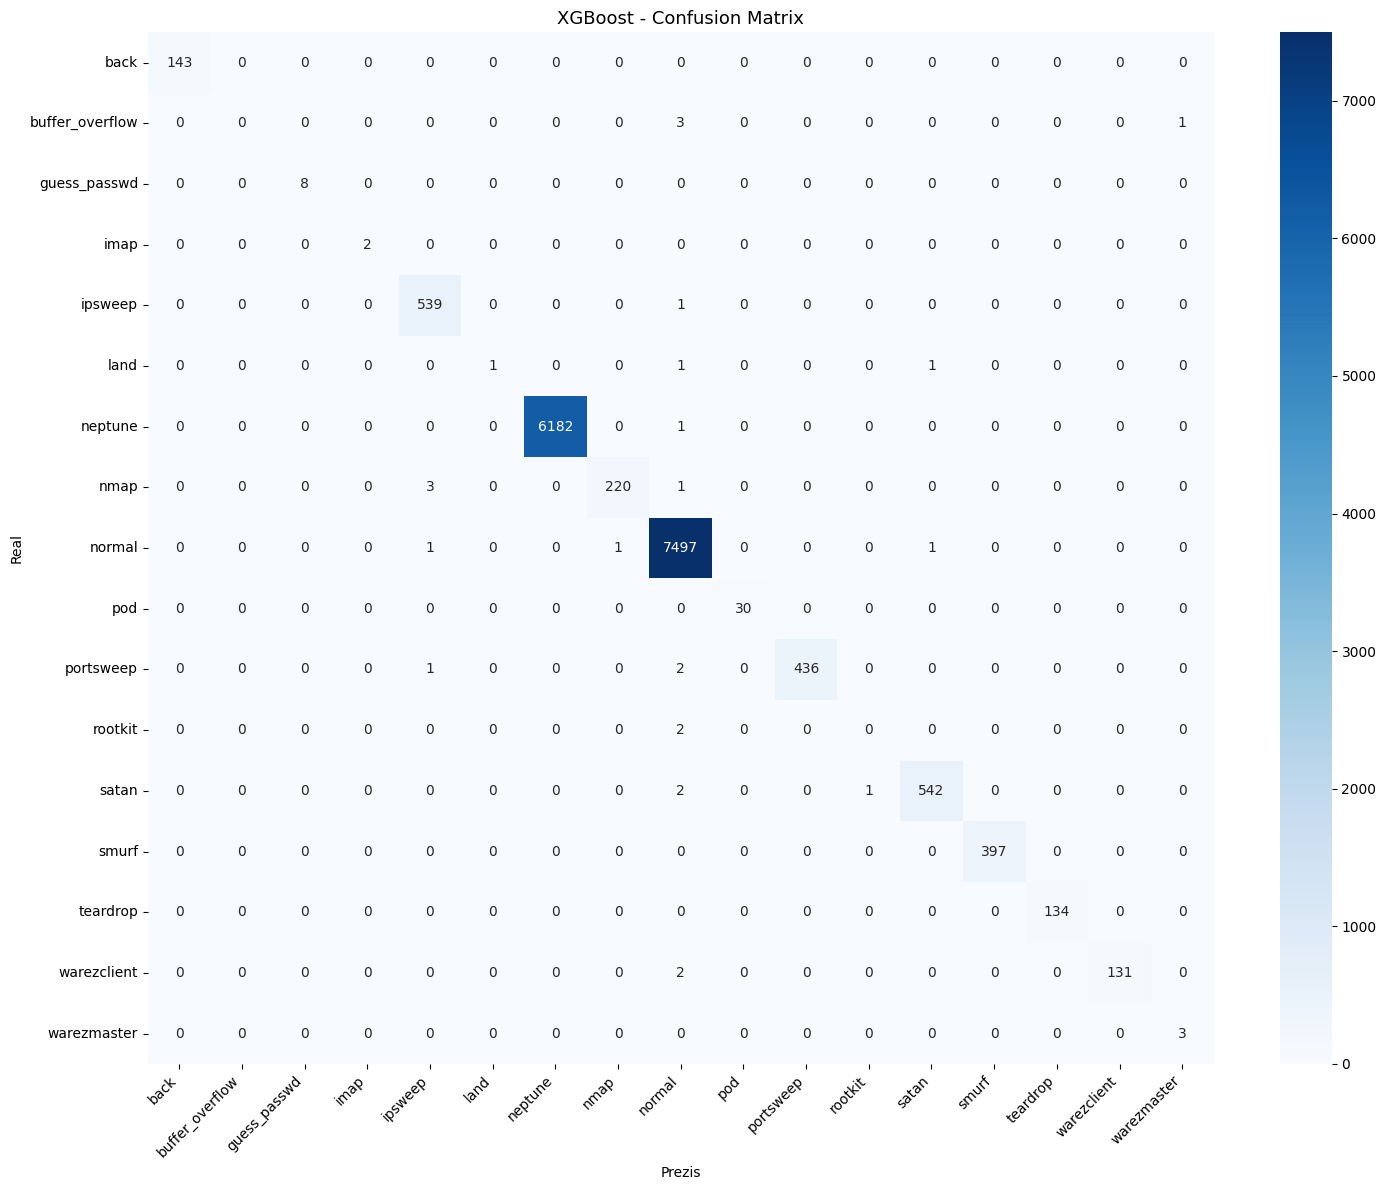

In [73]:
# Evaluare XGBoost
y_pred_xgb = xgb_model.predict(X_test_s)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print('=== XGBoost - Classification Report ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(15, 12))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('XGBoost - Confusion Matrix', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Prezis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

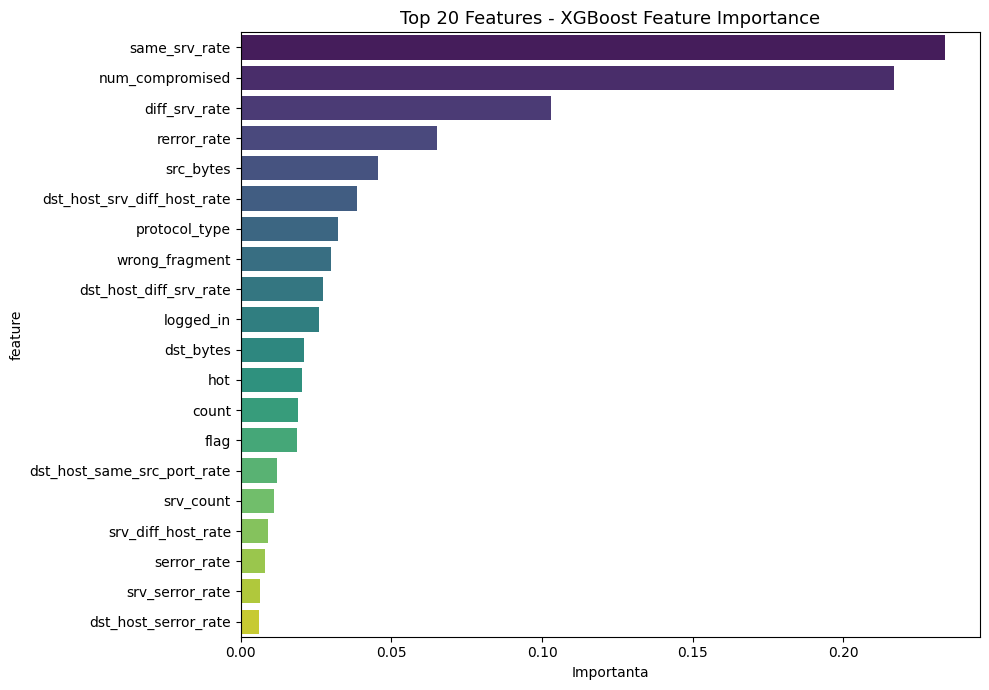

Top 10 features care detecteaza atacurile:
  same_srv_rate: 0.2337
  num_compromised: 0.2166
  diff_srv_rate: 0.1030
  rerror_rate: 0.0652
  src_bytes: 0.0457
  dst_host_srv_diff_host_rate: 0.0387
  protocol_type: 0.0322
  wrong_fragment: 0.0301
  dst_host_diff_srv_rate: 0.0272
  logged_in: 0.0260


In [74]:
# Feature Importance XGBoost
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Features - XGBoost Feature Importance', fontsize=13)
plt.xlabel('Importanta')
plt.tight_layout()
plt.show()

print('Top 10 features care detecteaza atacurile:')
for i, row in feat_df.head(10).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

## 6. Model 2 - MLP PyTorch

In [75]:
# Definire arhitectura MLP
class NIDS_MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_s.shape[1]
mlp_model = NIDS_MLP(input_dim, num_classes).to(device)
print(mlp_model)
print(f'\nParametri totali: {sum(p.numel() for p in mlp_model.parameters()):,}')

NIDS_MLP(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=17, bias=True)
  )
)

Parametri totali: 53,521


In [76]:
# DataLoaders PyTorch
def make_loader(X, y, batch_size=1024, shuffle=True):
    X_t = torch.FloatTensor(X)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val,   shuffle=False)
test_loader  = make_loader(X_test_s,  y_test,  shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print('DataLoaders gata.')

DataLoaders gata.


In [77]:
# Training loop MLP
EPOCHS = 30
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc, best_state = 0.0, None

t0 = time.time()

for epoch in range(EPOCHS):
    # --- Train ---
    mlp_model.train()
    t_loss, t_correct = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = mlp_model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * len(y_b)
        t_correct += (out.argmax(1) == y_b).sum().item()

    # --- Val ---
    mlp_model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = mlp_model(X_b)
            v_loss    += criterion(out, y_b).item() * len(y_b)
            v_correct += (out.argmax(1) == y_b).sum().item()

    train_loss = t_loss / len(train_loader.dataset)
    val_loss   = v_loss / len(val_loader.dataset)
    train_acc  = t_correct / len(train_loader.dataset)
    val_acc    = v_correct / len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f'Epoca {epoch+1:02d}/{EPOCHS} | loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | acc: {train_acc:.4f} | val_acc: {val_acc:.4f}')

mlp_model.load_state_dict(best_state)
mlp_train_time = time.time() - t0
print(f'\nAntrenare terminata in {mlp_train_time:.1f}s | Best val_acc: {best_val_acc:.4f}')

Epoca 05/30 | loss: 0.0518 | val_loss: 0.0381 | acc: 0.9851 | val_acc: 0.9884
Epoca 10/30 | loss: 0.0352 | val_loss: 0.0295 | acc: 0.9890 | val_acc: 0.9914
Epoca 15/30 | loss: 0.0291 | val_loss: 0.0233 | acc: 0.9909 | val_acc: 0.9931
Epoca 20/30 | loss: 0.0247 | val_loss: 0.0210 | acc: 0.9923 | val_acc: 0.9939
Epoca 25/30 | loss: 0.0217 | val_loss: 0.0202 | acc: 0.9934 | val_acc: 0.9942
Epoca 30/30 | loss: 0.0201 | val_loss: 0.0194 | acc: 0.9938 | val_acc: 0.9945

Antrenare terminata in 57.0s | Best val_acc: 0.9948


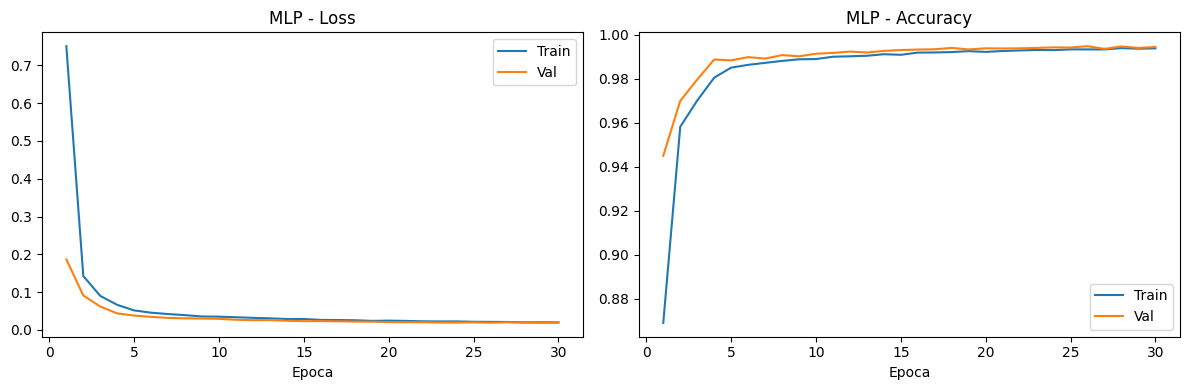

In [78]:
# Curbe antrenare MLP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'],   label='Val')
ax1.set_title('MLP - Loss')
ax1.set_xlabel('Epoca')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'],   label='Val')
ax2.set_title('MLP - Accuracy')
ax2.set_xlabel('Epoca')
ax2.legend()

plt.tight_layout()
plt.show()

=== MLP PyTorch - Classification Report ===
                 precision    recall  f1-score   support

           back       0.99      0.99      0.99       143
buffer_overflow       0.40      0.50      0.44         4
   guess_passwd       1.00      1.00      1.00         8
           imap       1.00      1.00      1.00         2
        ipsweep       0.97      0.99      0.98       540
           land       1.00      1.00      1.00         3
        neptune       1.00      1.00      1.00      6183
           nmap       0.98      0.97      0.98       224
         normal       1.00      1.00      1.00      7500
            pod       1.00      0.97      0.98        30
      portsweep       1.00      0.99      0.99       439
        rootkit       0.00      0.00      0.00         2
          satan       0.99      0.97      0.98       545
          smurf       1.00      0.99      0.99       397
       teardrop       1.00      1.00      1.00       134
    warezclient       0.93      0.95      0

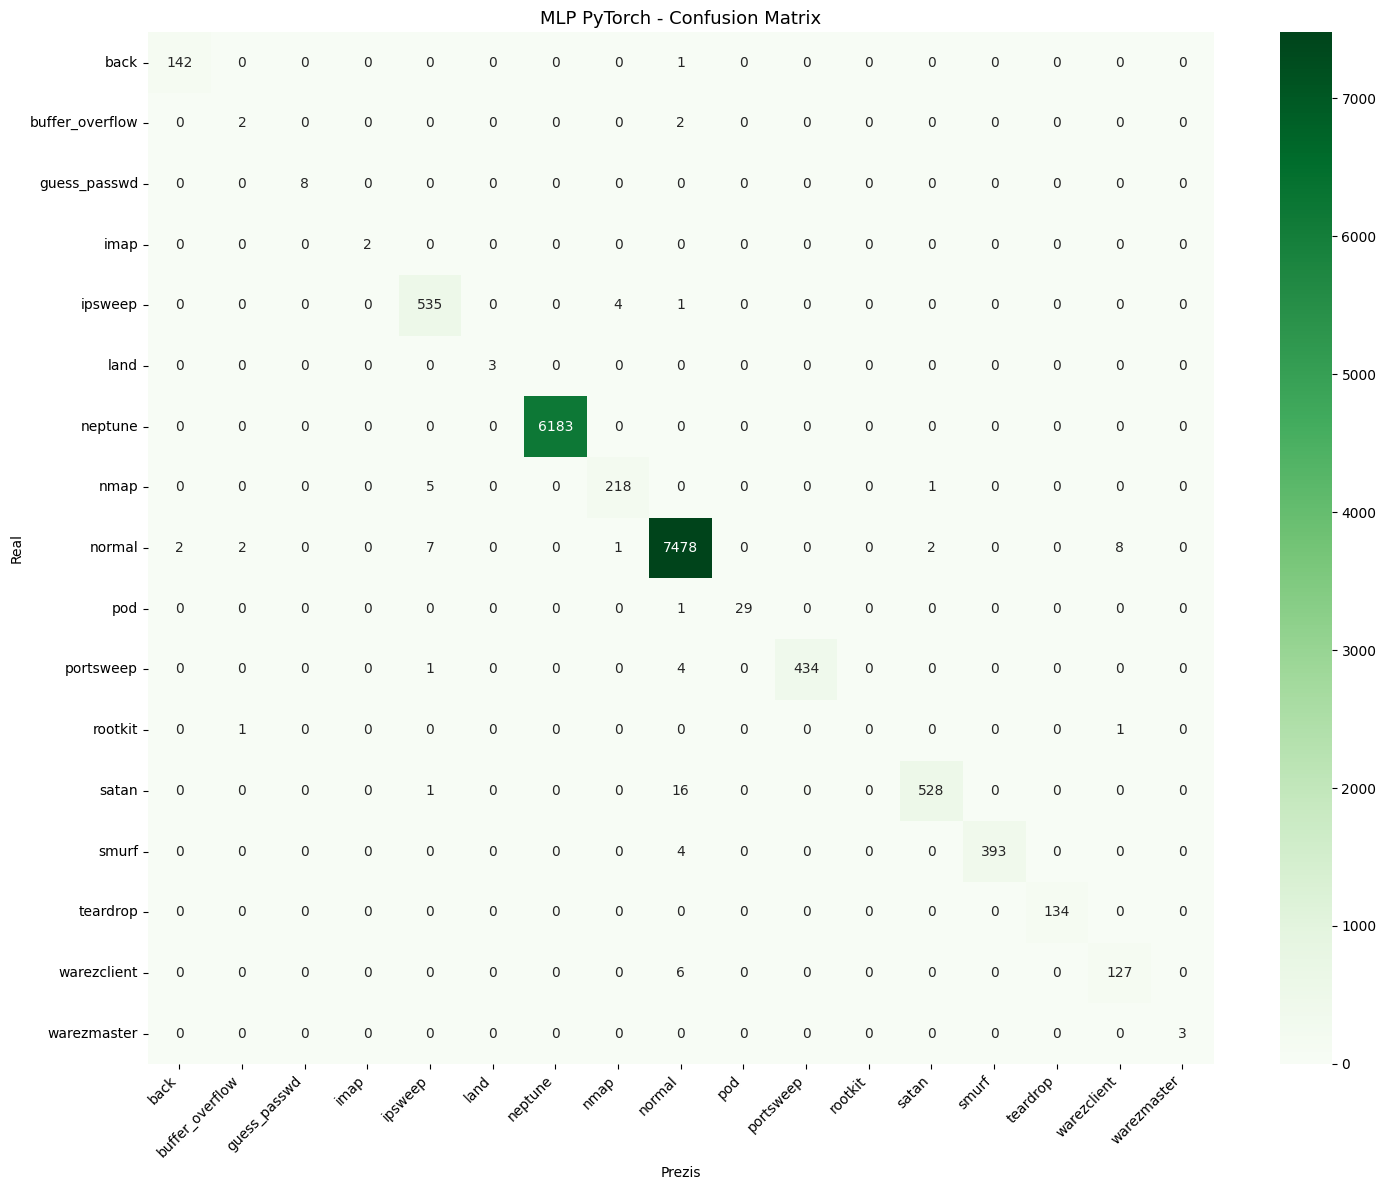

In [79]:
# Evaluare MLP pe test set
mlp_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        out = mlp_model(X_b.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y_b.numpy())

y_pred_mlp = np.array(all_preds)
mlp_f1 = f1_score(all_labels, y_pred_mlp, average='weighted')

print('=== MLP PyTorch - Classification Report ===')
print(classification_report(all_labels, y_pred_mlp, target_names=class_names))

# Confusion Matrix MLP
cm_mlp = confusion_matrix(all_labels, y_pred_mlp)
plt.figure(figsize=(15, 12))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MLP PyTorch - Confusion Matrix', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Prezis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

INCEPE TESTUL 1: Fara Dropout
-> Acuratete Test 1 (Fara Dropout): 0.9939

INCEPE TESTUL 2: Learning Rate crescut la 0.01
-> Acuratete Test 2 (High LR): 0.9934



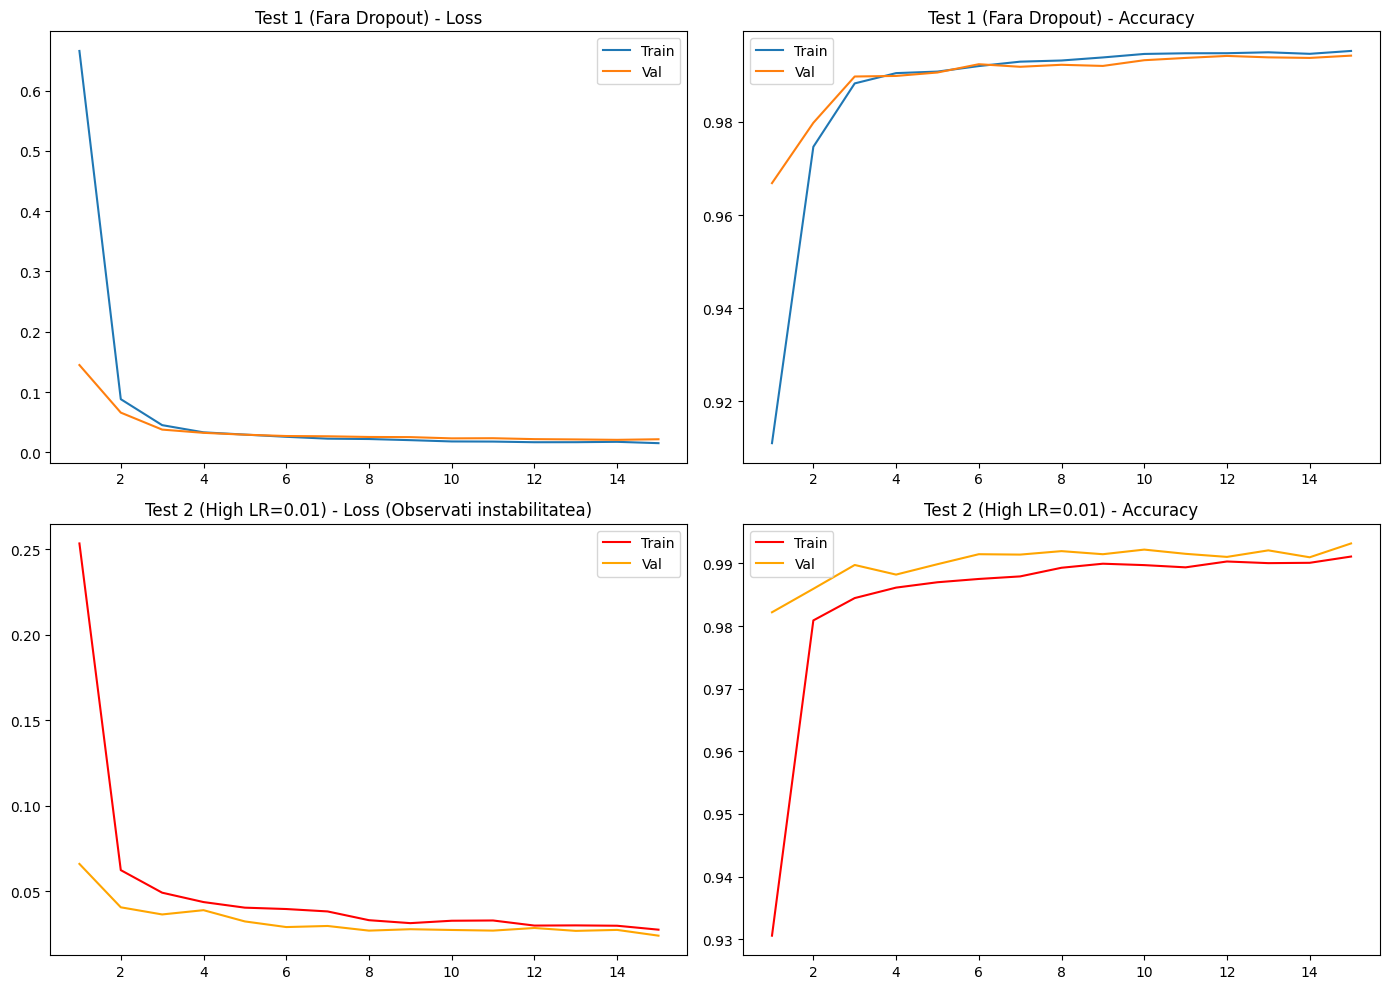

In [80]:
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

EPOCHS_TESTS = 15 # Folosim 15 epoci ca sa vedem rapid efectul

# TEST 1: ARHITECTURA ORIGINALA DAR FARA DROPOUT

print("INCEPE TESTUL 1: Fara Dropout")

class NIDS_MLP_NoDropout(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.Dropout(0.3) - ELIMINAT
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # nn.Dropout(0.3) - ELIMINAT
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_no_drop = NIDS_MLP_NoDropout(input_dim, num_classes).to(device)
opt_no_drop = optim.Adam(model_no_drop.parameters(), lr=0.001) # LR original
criterion = nn.CrossEntropyLoss()

hist_no_drop = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS_TESTS):
    model_no_drop.train()
    t_loss, t_correct = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        opt_no_drop.zero_grad()
        out = model_no_drop(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        opt_no_drop.step()
        t_loss += loss.item() * len(y_b)
        t_correct += (out.argmax(1) == y_b).sum().item()
        
    model_no_drop.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = model_no_drop(X_b)
            v_loss += criterion(out, y_b).item() * len(y_b)
            v_correct += (out.argmax(1) == y_b).sum().item()
            
    hist_no_drop['train_loss'].append(t_loss / len(train_loader.dataset))
    hist_no_drop['val_loss'].append(v_loss / len(val_loader.dataset))
    hist_no_drop['train_acc'].append(t_correct / len(train_loader.dataset))
    hist_no_drop['val_acc'].append(v_correct / len(val_loader.dataset))

# Evaluare Test 1
model_no_drop.eval()
preds_nd, labels_nd = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds_nd.extend(model_no_drop(X_b.to(device)).argmax(1).cpu().numpy())
        labels_nd.extend(y_b.numpy())
acc_nd = accuracy_score(labels_nd, preds_nd)
print(f"-> Acuratete Test 1 (Fara Dropout): {acc_nd:.4f}\n")



# TEST 2: ARHITECTURA ORIGINALA (CU DROPOUT) DAR LR MAI MARE (0.01)

print("INCEPE TESTUL 2: Learning Rate crescut la 0.01")

class NIDS_MLP_HighLR(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3), # READAUGAT (Original)
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3), # READAUGAT (Original)
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_high_lr = NIDS_MLP_HighLR(input_dim, num_classes).to(device)
opt_high_lr = optim.Adam(model_high_lr.parameters(), lr=0.01) # LR MULT MAI MARE
hist_high_lr = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS_TESTS):
    model_high_lr.train()
    t_loss, t_correct = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        opt_high_lr.zero_grad()
        out = model_high_lr(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        opt_high_lr.step()
        t_loss += loss.item() * len(y_b)
        t_correct += (out.argmax(1) == y_b).sum().item()
        
    model_high_lr.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = model_high_lr(X_b)
            v_loss += criterion(out, y_b).item() * len(y_b)
            v_correct += (out.argmax(1) == y_b).sum().item()
            
    hist_high_lr['train_loss'].append(t_loss / len(train_loader.dataset))
    hist_high_lr['val_loss'].append(v_loss / len(val_loader.dataset))
    hist_high_lr['train_acc'].append(t_correct / len(train_loader.dataset))
    hist_high_lr['val_acc'].append(v_correct / len(val_loader.dataset))

# Evaluare Test 2
model_high_lr.eval()
preds_hlr, labels_hlr = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds_hlr.extend(model_high_lr(X_b.to(device)).argmax(1).cpu().numpy())
        labels_hlr.extend(y_b.numpy())
acc_hlr = accuracy_score(labels_hlr, preds_hlr)
print(f"-> Acuratete Test 2 (High LR): {acc_hlr:.4f}\n")



# AFISARE GRAFICE COMPARATIVE

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, EPOCHS_TESTS + 1)

# Randul 1: Test 1 (Fara Dropout)
axs[0, 0].plot(ep, hist_no_drop['train_loss'], label='Train')
axs[0, 0].plot(ep, hist_no_drop['val_loss'], label='Val')
axs[0, 0].set_title('Test 1 (Fara Dropout) - Loss')
axs[0, 0].legend()

axs[0, 1].plot(ep, hist_no_drop['train_acc'], label='Train')
axs[0, 1].plot(ep, hist_no_drop['val_acc'], label='Val')
axs[0, 1].set_title('Test 1 (Fara Dropout) - Accuracy')
axs[0, 1].legend()

# Randul 2: Test 2 (High LR)
axs[1, 0].plot(ep, hist_high_lr['train_loss'], label='Train', color='red')
axs[1, 0].plot(ep, hist_high_lr['val_loss'], label='Val', color='orange')
axs[1, 0].set_title('Test 2 (High LR=0.01) - Loss (Observati instabilitatea)')
axs[1, 0].legend()

axs[1, 1].plot(ep, hist_high_lr['train_acc'], label='Train', color='red')
axs[1, 1].plot(ep, hist_high_lr['val_acc'], label='Val', color='orange')
axs[1, 1].set_title('Test 2 (High LR=0.01) - Accuracy')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

NIDS_MLP_V2(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=17, bias=True)
  )
)

Parametri totali (V2): 5,393

Antrenare MLP Varianta 2...
Epoca 01/15 | loss: 0.5582 | val_loss: 0.1386 | acc: 0.8863 | val_acc: 0.9561
Epoca 02/15 | loss: 0.0970 | val_loss: 0.0660 | acc: 0.9695 | val_acc: 0.9772
Epoca 03/15 | loss: 0.0512 | val_loss: 0.0415 | acc: 0.9867 | val_acc: 0.9896
Epoca 04/15 | loss: 0.0385 | val_loss: 0.0362 | acc: 0.9896 | val_acc: 0.9902
Epoca 05/15 | loss: 0.0334 | val_loss: 0.0338 | acc: 0.9902 | val_acc: 0.9882
Epoca 06/15 | loss: 0.0325 | val_loss: 0.0291 | acc: 0.9907 | val_acc: 0.9911
Epoca 07/15 | loss: 0.0290 | val_loss: 0.0279 | acc: 0.9916 | val_acc: 0.9917
Epoca 08/15 | loss: 0.0276 | val_loss: 0.0284 | acc: 0

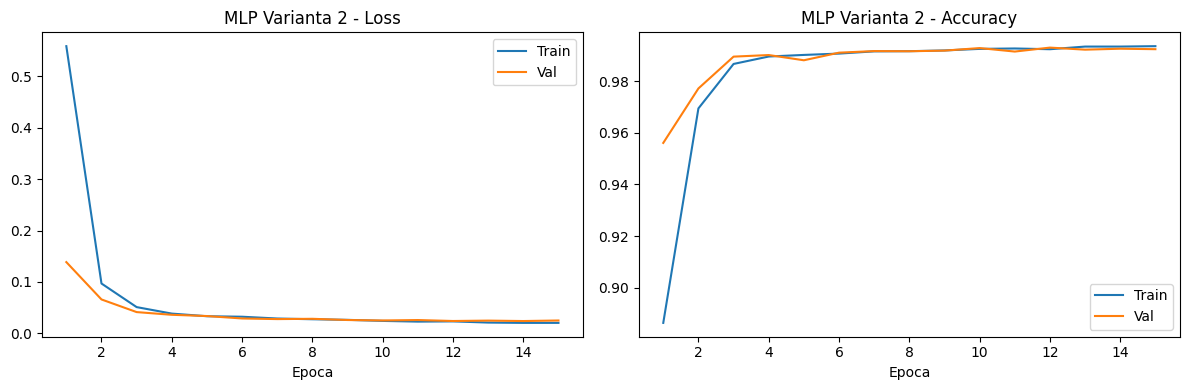


=== Rezultat Experiment ===
Acuratete MLP V2 pe datele noi (Test): 0.9923


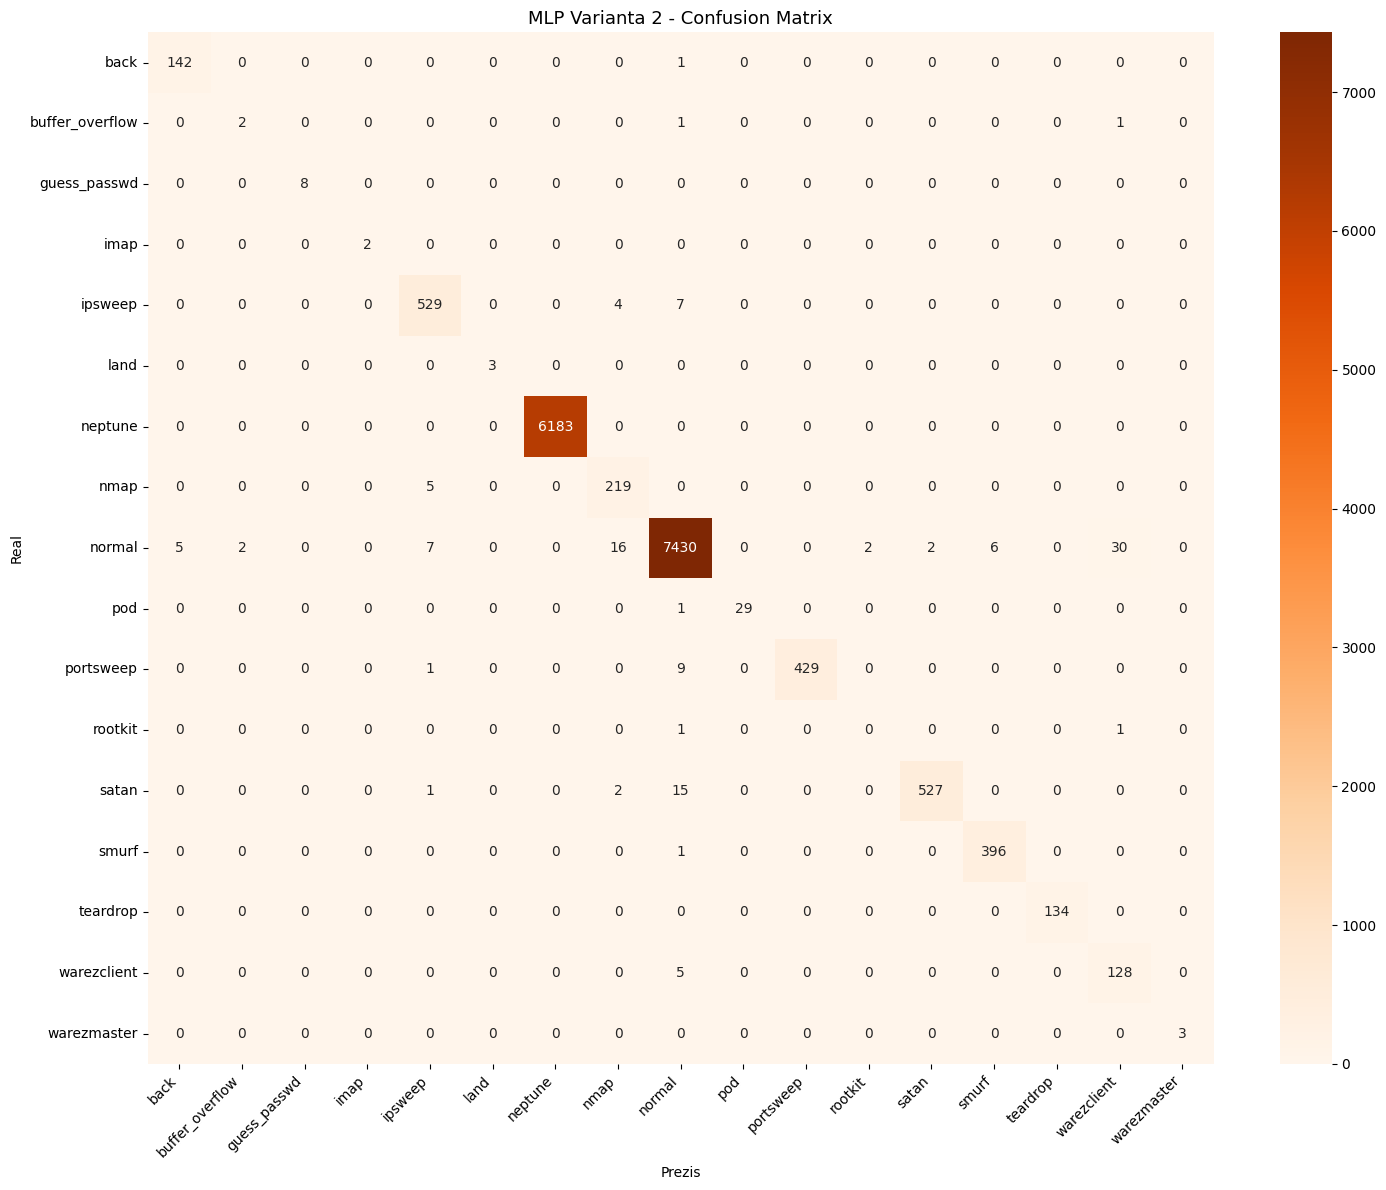

In [81]:

# EXPERIMENT: MLP Varianta 2 (fara Dropout, LR mai mare)

import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim

class NIDS_MLP_V2(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), # Mult mai putini neuroni
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # Am scos Dropout-ul complet

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Initializam noul model
mlp_v2 = NIDS_MLP_V2(input_dim, num_classes).to(device)
print(mlp_v2)
print(f'\nParametri totali (V2): {sum(p.numel() for p in mlp_v2.parameters()):,}')

# Folosim un Learning Rate mai mare (0.005 fata de 0.001)
optimizer_v2 = optim.Adam(mlp_v2.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

# Cream dictionarul pentru a salva istoricul graficelor
history_v2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# Antrenam pe 15 epoci
EPOCHS_V2 = 15
print('\nAntrenare MLP Varianta 2...')
t0_v2 = time.time()

for epoch in range(EPOCHS_V2):
    # --- Partea de Antrenare (Train) ---
    mlp_v2.train()
    t_loss, t_correct = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_v2.zero_grad()
        out = mlp_v2(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer_v2.step()
        
        t_loss += loss.item() * len(y_b)
        t_correct += (out.argmax(1) == y_b).sum().item()
        
    # --- Partea de Validare (Val) ---
    mlp_v2.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = mlp_v2(X_b)
            v_loss += criterion(out, y_b).item() * len(y_b)
            v_correct += (out.argmax(1) == y_b).sum().item()
            
    # Calculam mediile pe epoca si le salvam in istoric
    train_loss = t_loss / len(train_loader.dataset)
    val_loss   = v_loss / len(val_loader.dataset)
    train_acc  = t_correct / len(train_loader.dataset)
    val_acc    = v_correct / len(val_loader.dataset)
    
    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['train_acc'].append(train_acc)
    history_v2['val_acc'].append(val_acc)
    
    # Afisam progresul
    print(f'Epoca {epoch+1:02d}/{EPOCHS_V2} | loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | acc: {train_acc:.4f} | val_acc: {val_acc:.4f}')

mlp_v2_time = time.time() - t0_v2
print(f'\nAntrenare terminata in {mlp_v2_time:.1f}s')

# 1. AFISARE GRAFICE DE ANTRENARE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS_V2 + 1)

ax1.plot(epochs_range, history_v2['train_loss'], label='Train')
ax1.plot(epochs_range, history_v2['val_loss'],   label='Val')
ax1.set_title('MLP Varianta 2 - Loss')
ax1.set_xlabel('Epoca')
ax1.legend()

ax2.plot(epochs_range, history_v2['train_acc'], label='Train')
ax2.plot(epochs_range, history_v2['val_acc'],   label='Val')
ax2.set_title('MLP Varianta 2 - Accuracy')
ax2.set_xlabel('Epoca')
ax2.legend()

plt.tight_layout()
plt.show()


# 2. EVALUARE RAPIDA PE SETUL DE TEST

mlp_v2.eval()
all_preds_v2, all_labels_v2 = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = mlp_v2(X_b.to(device))
        all_preds_v2.extend(out.argmax(1).cpu().numpy())
        all_labels_v2.extend(y_b.numpy())

acc_v2 = accuracy_score(all_labels_v2, all_preds_v2)
print(f'\n=== Rezultat Experiment ===')
print(f'Acuratete MLP V2 pe datele noi (Test): {acc_v2:.4f}')

# 3. AFISARE MATRICE DE CONFUZIE PENTRU V2
cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
plt.figure(figsize=(15, 12)) # La fel de mare ca prima ca sa incapa toate clasele
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MLP Varianta 2 - Confusion Matrix', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Prezis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Comparatie Modele

=== COMPARATIE FINALA ===
      Model  Accuracy  F1 Weighted Timp antrenare
    XGBoost  0.998465     0.998285          24.2s
MLP PyTorch  0.995641     0.995598          57.0s


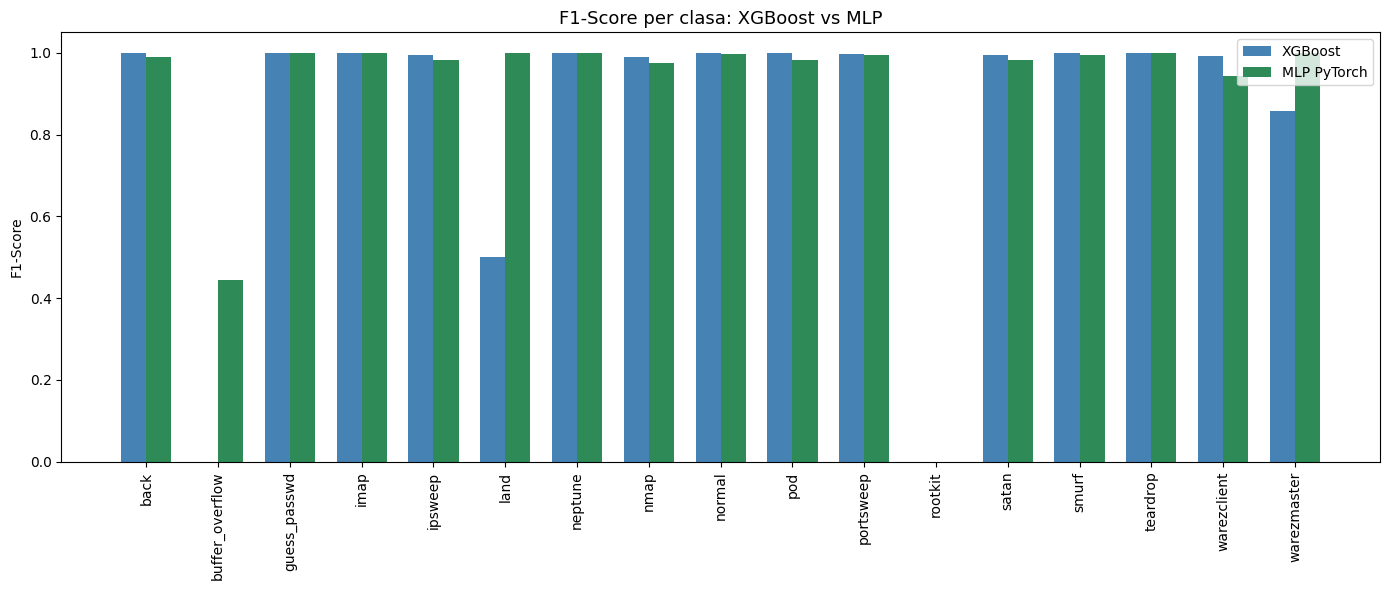

In [82]:
# Tabel comparativ
from sklearn.metrics import accuracy_score

results = {
    'Model':           ['XGBoost',        'MLP PyTorch'],
    'Accuracy':        [accuracy_score(y_test, y_pred_xgb), accuracy_score(all_labels, y_pred_mlp)],
    'F1 Weighted':     [xgb_f1,           mlp_f1],
    'Timp antrenare':  [f'{xgb_train_time:.1f}s', f'{mlp_train_time:.1f}s'],
}

results_df = pd.DataFrame(results)
print('COMPARATIE FINALA')
print(results_df.to_string(index=False))

# Grafic comparativ F1 per clasa
from sklearn.metrics import f1_score
f1_xgb = f1_score(y_test, y_pred_xgb, average=None, labels=range(num_classes))
f1_mlp = f1_score(all_labels, y_pred_mlp, average=None, labels=range(num_classes))

x = np.arange(num_classes)
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_xgb, width, label='XGBoost', color='steelblue')
ax.bar(x + width/2, f1_mlp, width, label='MLP PyTorch', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=90, ha='center')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per clasa: XGBoost vs MLP', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Inferenta pe Flux Nou

In [83]:
def predict_traffic(flow_features, model_type='xgb'):
    """
    Prezice tipul unui flux de retea.
    
    Args:
        flow_features: dict sau array cu valorile celor features
        model_type: 'xgb' sau 'mlp'
    
    Returns:
        (predicted_class, confidence)
    """
    if isinstance(flow_features, dict):
        flow_arr = np.array([flow_features.get(f, 0) for f in feature_cols]).reshape(1, -1)
    else:
        flow_arr = np.array(flow_features).reshape(1, -1)

    flow_scaled = scaler.transform(flow_arr)

    if model_type == 'xgb':
        pred = xgb_model.predict(flow_scaled)[0]
        proba = xgb_model.predict_proba(flow_scaled)[0]
    else:
        mlp_model.eval()
        with torch.no_grad():
            t = torch.FloatTensor(flow_scaled).to(device)
            logits = mlp_model(t)
            proba = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = proba.argmax()

    predicted_class = class_names[pred]
    confidence = proba[pred]
    is_malicious = predicted_class.lower() != 'normal'

    print(f'Clasa prezisa: {predicted_class}')
    print(f'Confidence:    {confidence*100:.1f}%')
    print(f'Status:        {"MALITIOS" if is_malicious else "NORMAL"}')
    print()
    print('Top 3 probabilitati:')
    top3 = np.argsort(proba)[::-1][:3]
    for i in top3:
        print(f'  {class_names[i]}: {proba[i]*100:.1f}%')

    return predicted_class, confidence

# Test pe un exemplu din test set
print('Inferenta pe primul sample din test set')
predict_traffic(X_test[0], model_type='xgb')
print(f'Label real: {class_names[y_test[0]]}')

=== Inferenta pe primul sample din test set ===
Clasa prezisa: neptune
Confidence:    100.0%
Status:        MALITIOS

Top 3 probabilitati:
  neptune: 100.0%
  normal: 0.0%
  satan: 0.0%
Label real: neptune


## 9. Salvare Modele

In [84]:
import joblib

# Salvare XGBoost + scaler + label encoder
joblib.dump(xgb_model, '/kaggle/working/xgb_nids.pkl')
joblib.dump(scaler,    '/kaggle/working/scaler.pkl')
joblib.dump(le,        '/kaggle/working/label_encoder.pkl')
joblib.dump(feature_cols, '/kaggle/working/feature_cols.pkl')

# Salvare MLP PyTorch
torch.save({
    'model_state':  mlp_model.state_dict(),
    'input_dim':    input_dim,
    'num_classes':  num_classes,
    'class_names':  class_names,
}, '/kaggle/working/mlp_nids.pth')

print('Modele salvate in /kaggle/working/')
print('  xgb_nids.pkl       - XGBoost model')
print('  scaler.pkl         - StandardScaler')
print('  label_encoder.pkl  - LabelEncoder')
print('  feature_cols.pkl   - lista de features')
print('  mlp_nids.pth       - MLP PyTorch')

Modele salvate in /kaggle/working/
  xgb_nids.pkl       - XGBoost model
  scaler.pkl         - StandardScaler
  label_encoder.pkl  - LabelEncoder
  feature_cols.pkl   - lista de features
  mlp_nids.pth       - MLP PyTorch
